In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MASTER = 'Pathways Master.xlsx'

In [41]:
def make_df(tab):
    df = pd.read_excel(MASTER, tab, usecols=range(0, 12))[:16] #Read in data from a tab, use just columns w raw data
    df = df.rename(columns={'Unnamed: 0': 'Community Colleges'}) #Name indx column
    df.set_index('Community Colleges', inplace=True) #set indx
    df = df.astype(float) #make all values floats
    return df

In [42]:
total_ch = make_df('Credit Hours') # Total Credit Hours per Degree
pct_as = make_df('% Credit Hours') #Percent of AS that Transfers
curr_comp = make_df('Curricular Complexity') # Curricular Complexity
cost = make_df('Cost') # Cost

In [43]:
def make_graph(df, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    # make boxplot of just transfer degrees
    sns.boxplot(data=df.loc['Berkshire':], linewidth=1.5, zorder=1)
    
    # overlay (z=2) scatterplot with just res degrees 
    if ylabel != 'Percent of AS':
        plt.scatter(df.columns, df.loc['Resident'], color='teal', label='Resident Degrees', zorder=2)
    
    #Customization!! :D
    if filename=='cost':
        plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend()
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(fontsize=10, rotation=90)
    plt.yticks(fontsize=10)
    plt.savefig(f'images/{filename}.png', bbox_inches = 'tight')
    plt.show()

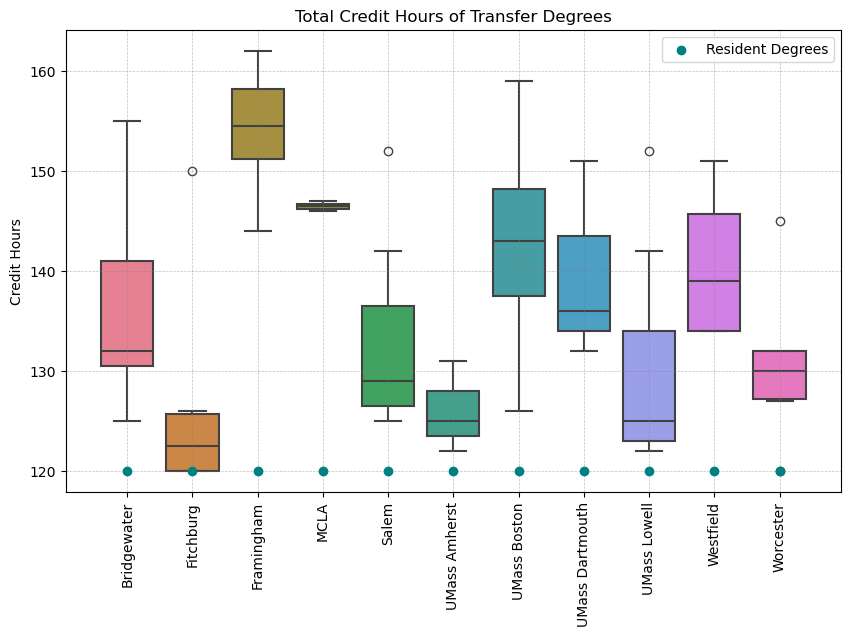

In [44]:
make_graph(total_ch, 'Total Credit Hours of Transfer Degrees', 'Credit Hours', 'total_ch')

/var/folders/5_/wyyt684n44q4_557k6crj7180000gn/T/ipykernel_65484/1680991307.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


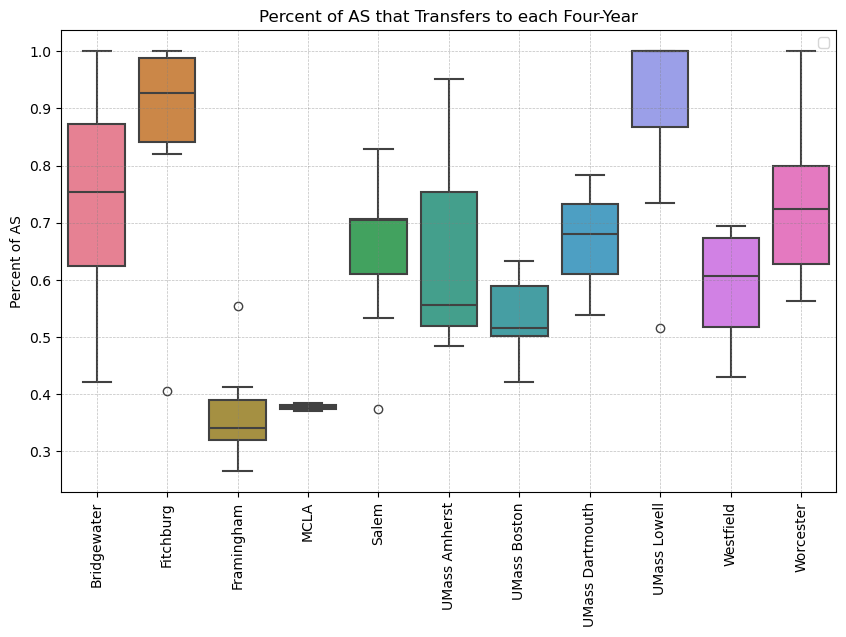

In [ ]:
make_graph(pct_as, 'Percent of ASCS that Transfers to each Four-Year', 'Percent of AS', 'pct_as')

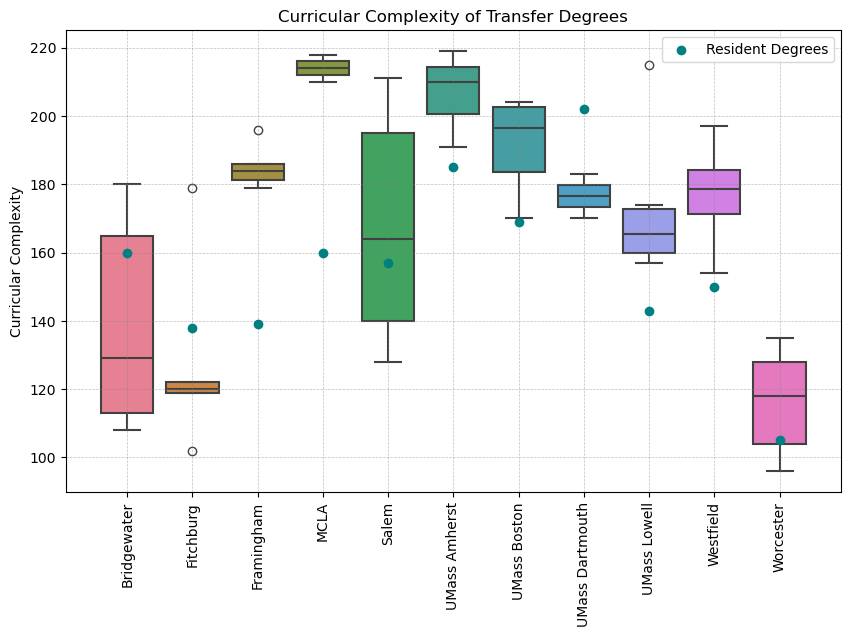

In [ ]:
make_graph(curr_comp, 'Curricular Complexity of Transfer vs Resident Degrees', 'Curricular Complexity', 'curr_comp')

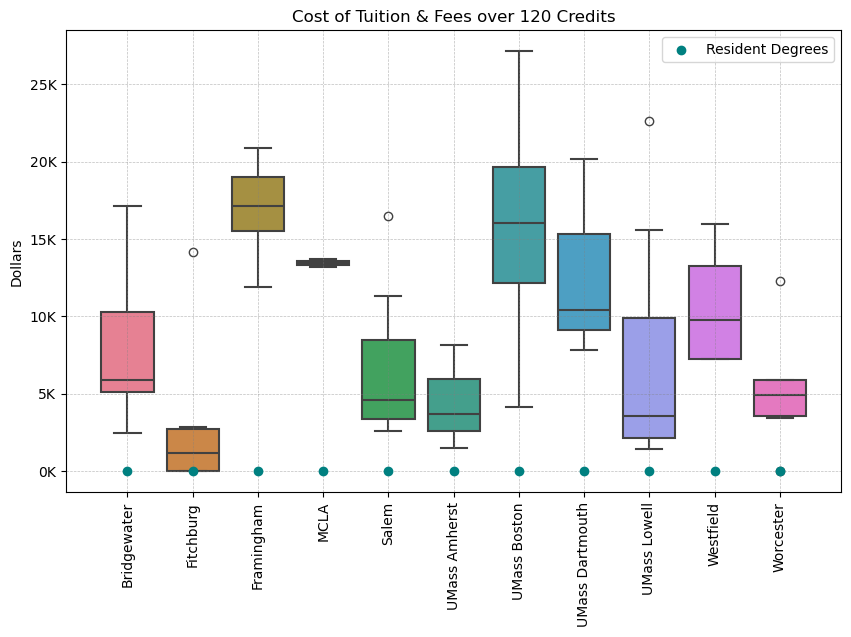

In [47]:
make_graph(cost, 'Cost of Tuition & Fees over 120 Credits', 'Dollars', 'cost')

In [48]:

pct_as_melt = pct_as.melt(var_name='Category', value_name='pct_as')
total_ch_melt = total_ch.melt(var_name='Category', value_name='total_ch')
curr_comp_melt = curr_comp.melt(var_name='Category', value_name='curr_comp')
cost_melt = cost.melt(var_name='Category', value_name='cost')
cat_df = pd.concat([pct_as_melt, total_ch_melt['total_ch'], curr_comp_melt['curr_comp'], cost_melt['cost']], axis=1)

In [49]:
cat_df

,Category,pct_as,total_ch,curr_comp,cost
0,Bridgewater,1.000000,120.0,160.0,0.000000
1,Bridgewater,NaN,NaN,NaN,NaN
2,Bridgewater,0.739130,130.0,165.0,4889.166667
3,Bridgewater,0.508197,149.0,180.0,14178.583330
4,Bridgewater,0.753623,131.0,113.0,5378.083333
...,...,...,...,...,...
171,Worcester,NaN,NaN,NaN,NaN
172,Worcester,NaN,NaN,NaN,NaN
173,Worcester,1.000000,120.0,96.0,0.000000
174,Worcester,0.562500,145.0,NaN,12277.083330


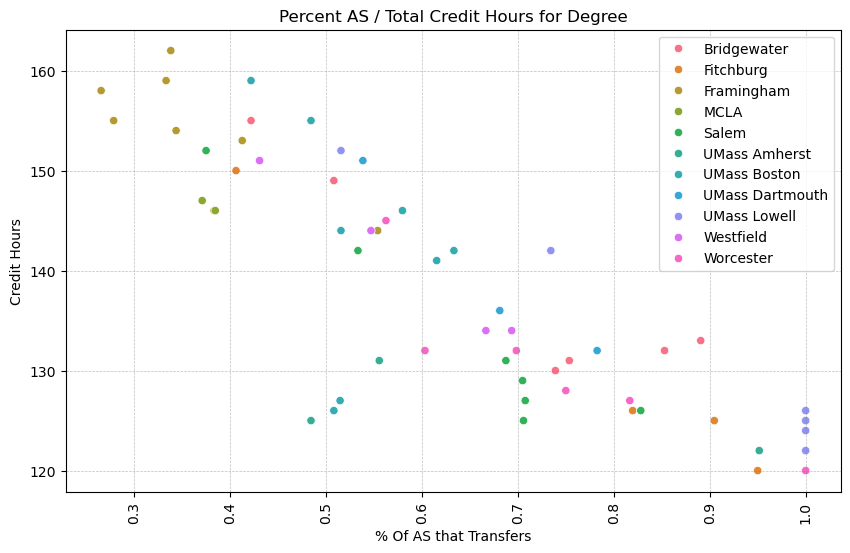

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['pct_as'], y=cat_df['total_ch'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Percent AS / Total Credit Hours for Degree')
plt.ylabel('Credit Hours')
plt.xlabel('% Of AS that Transfers')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/pct-total.png', bbox_inches = 'tight')
plt.show()

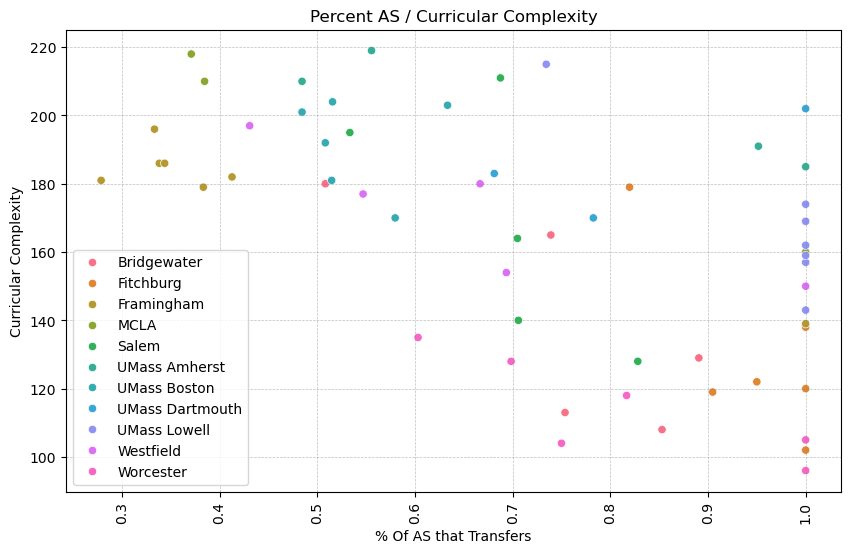

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['pct_as'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Percent AS / Curricular Complexity')
plt.ylabel('Curricular Complexity')
plt.xlabel('% Of AS that Transfers')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/pct-curr_comp.png', bbox_inches = 'tight')
plt.show()

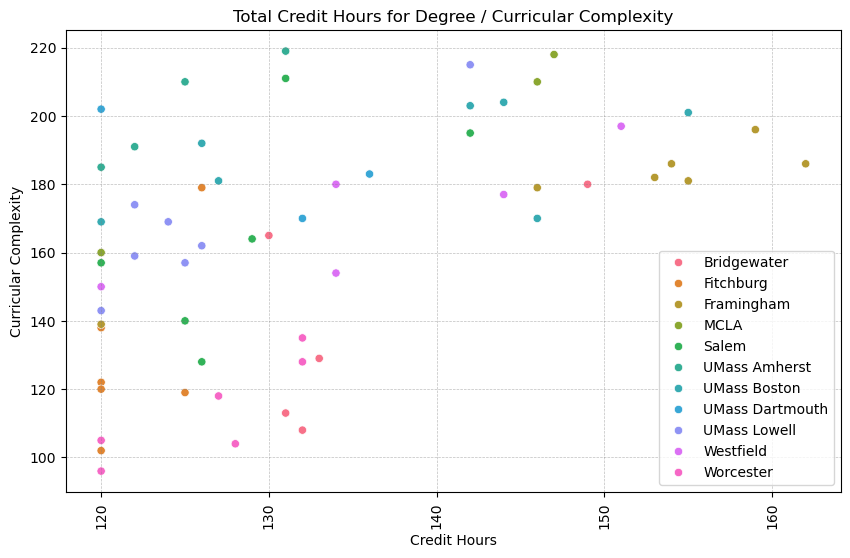

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['total_ch'], y=cat_df['curr_comp'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Total Credit Hours for Degree / Curricular Complexity')
plt.ylabel('Curricular Complexity')
plt.xlabel('Credit Hours')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/total-curr_comp.png', bbox_inches = 'tight')
plt.show()

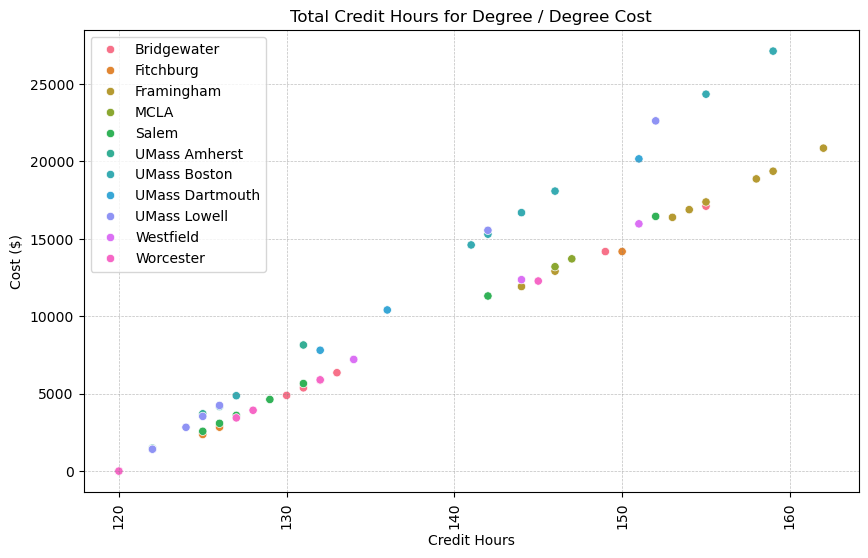

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cat_df['total_ch'], y=cat_df['cost'], hue=cat_df['Category'])
# plt.scatter(pct_as, total_ch)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.title('Total Credit Hours for Degree / Degree Cost')
plt.ylabel('Cost ($)')
plt.xlabel('Credit Hours')
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.savefig('images/total-cost.png', bbox_inches = 'tight')
plt.show()

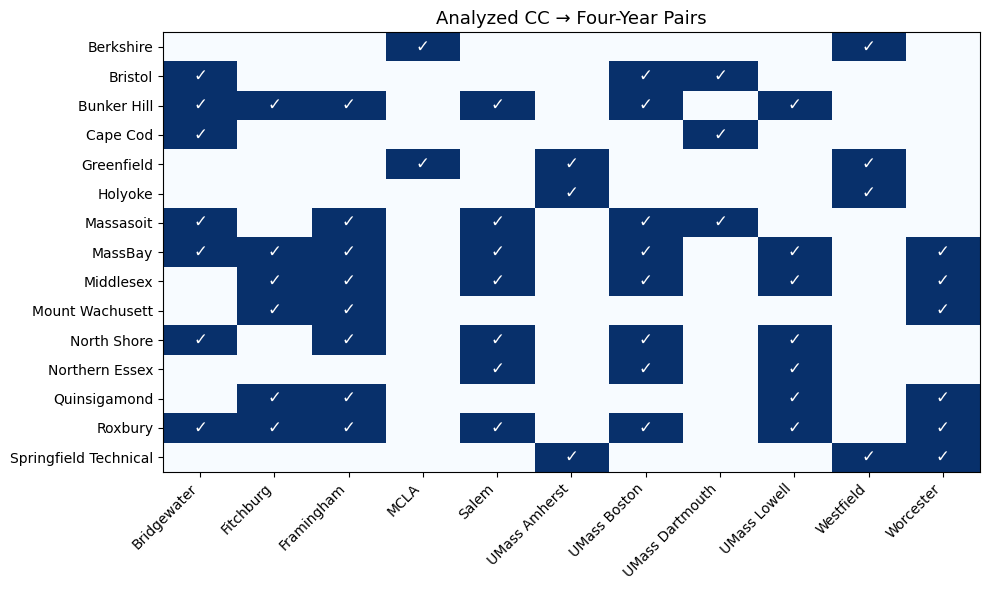

In [ ]:
# Matrix of analyzed CC → 4-year pairs
analyzed = total_ch.loc['Berkshire':].notna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(analyzed.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(analyzed.columns)))
ax.set_xticklabels(analyzed.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(analyzed.index)))
ax.set_yticklabels(analyzed.index, fontsize=10)

for i in range(len(analyzed.index)):
    for j in range(len(analyzed.columns)):
        ax.text(j, i, '✓' if analyzed.values[i, j] else '', ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')

ax.set_title('Community Colleges and 4-Years within 50 Miles of Eachother', fontsize=13)
plt.tight_layout()
plt.savefig('images/analyzed_pairs.png', bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import Reds, Greens

cc = slice('Berkshire', None)

avg_pct  = pct_as.loc[cc].mean()
avg_ch   = (total_ch.loc[cc] - total_ch.loc['Resident']).mean()
avg_cc   = (curr_comp.loc[cc] - curr_comp.loc['Resident']).mean()
avg_cost = (cost.loc[cc] - cost.loc['Resident']).mean()

metrics = {
    'Avg % AS Transfer':          (avg_pct,  True,  '{:.0%}'),
    'Avg Extra Credit Hours':     (avg_ch,   False, '{:+.1f}'),
    'Avg Extra Curr. Complexity': (avg_cc,   False, '{:+.1f}'),
    'Avg Extra Cost':             (avg_cost, False, '${:,.0f}'),
}

unis = avg_pct.index.tolist()
col_labels = [u.replace('UMass ', '') for u in unis]
cell_text, cell_colors = [], []

for label, (series, higher_is_better, fmt) in metrics.items():
    row_vals = series.reindex(unis)
    cell_text.append([fmt.format(v) if not np.isnan(v) else '—' for v in row_vals])

    pos_vals = row_vals[row_vals >= 0]
    neg_vals = row_vals[row_vals < 0]
    pos_norm = Normalize(vmin=pos_vals.min() if len(pos_vals) else 0, vmax=pos_vals.max() if len(pos_vals) else 1)
    neg_norm = Normalize(vmin=neg_vals.min() if len(neg_vals) else -1, vmax=0)

    colors = []
    for v in row_vals:
        if np.isnan(v):
            colors.append('#f5f5f5')
        elif v < 0:
            colors.append(Greens(0.2 + (1 - neg_norm(v)) * 0.45))
        else:
            scalar = (1 - pos_norm(v)) if higher_is_better else pos_norm(v)
            colors.append(Reds(0.15 + scalar * 0.4))
    cell_colors.append(colors)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=list(metrics.keys()),
    colLabels=col_labels,
    cellLoc='center',
    bbox=[0, 0, 1, 1],
    cellColours=cell_colors,
)
table.auto_set_font_size(False)
table.set_fontsize(9)

for j in range(len(unis)):
    cell = table[(0, j)]
    cell.set_facecolor('#2d6a4f')
    cell.set_text_props(color='white', fontweight='bold')

for i in range(len(metrics)):
    table[(i + 1, -1)].set_facecolor('#f0f0f0')
    table[(i + 1, -1)].set_text_props(fontweight='bold')

ax.set_title('Four-Year Scorecard: Average Transfer Pathway Outcomes', fontsize=13, fontweight='bold', pad=4)
fig.subplots_adjust(top=0.9, bottom=0, left=0.18, right=1.0)
plt.savefig('images/scorecard.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
data = pct_as.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')
data.loc['Average'] = data.mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(data.values, cmap='Greens', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index, fontsize=10)

for i in range(len(data.index)):
    for j in range(len(data.columns)):
        v = data.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=9, color='white')

ax.set_title('Percent of AS that Transfers to Each Four-Year', fontsize=13)
plt.tight_layout()
plt.savefig('images/pct_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
extra_cc = curr_comp.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')
extra_cc = extra_cc.subtract(curr_comp.loc['Resident'])
extra_cc.loc['Average'] = extra_cc.mean()

from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=extra_cc.min().min(), vcenter=0, vmax=extra_cc.max().max())

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(extra_cc.values, cmap='RdYlGn_r', aspect='auto', norm=norm)

ax.set_xticks(range(len(extra_cc.columns)))
ax.set_xticklabels(extra_cc.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(extra_cc.index)))
ax.set_yticklabels(extra_cc.index, fontsize=10)

for i in range(len(extra_cc.index)):
    for j in range(len(extra_cc.columns)):
        v = extra_cc.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.0f}', ha='center', va='center', fontsize=9, color='black')

ax.set_title('Extra Curricular Complexity Points vs. Resident Degree', fontsize=13)
plt.tight_layout()
plt.savefig('images/curr_comp_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
extra_ch = total_ch.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore') - 120
extra_ch.loc['Average'] = extra_ch.mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(extra_ch.values, cmap='Reds', aspect='auto', vmin=0, vmax=extra_ch.max().max() * 1.5)

ax.set_xticks(range(len(extra_ch.columns)))
ax.set_xticklabels(extra_ch.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(extra_ch.index)))
ax.set_yticklabels(extra_ch.index, fontsize=10)

for i in range(len(extra_ch.index)):
    for j in range(len(extra_ch.columns)):
        v = extra_ch.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'+{v:.0f}', ha='center', va='center', fontsize=9, color='black')

ax.set_title('Extra Credit Hours Above 120', fontsize=13)
plt.tight_layout()
plt.savefig('images/extra_ch_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
extra_cost = cost.loc['Berkshire':].drop(index=['Median', 'Range'], errors='ignore')
extra_cost.loc['Average'] = extra_cost.mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(extra_cost.values, cmap='Reds', aspect='auto', vmin=0, vmax=extra_cost.max().max() * 1.5)

ax.set_xticks(range(len(extra_cost.columns)))
ax.set_xticklabels(extra_cost.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(extra_cost.index)))
ax.set_yticklabels(extra_cost.index, fontsize=10)

for i in range(len(extra_cost.index)):
    for j in range(len(extra_cost.columns)):
        v = extra_cost.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'${v:,.0f}', ha='center', va='center', fontsize=9, color='black')

ax.set_title('Extra Tuition Cost Above Resident Degree', fontsize=13)
plt.tight_layout()
plt.savefig('images/cost_matrix.png', bbox_inches='tight')
plt.show()